# Tutorial 05 — SHAP: Giải Thích Quyết Định Của Mô Hình

> **Mục tiêu:** Dùng SHAP để mô hình "giải thích" tại sao nó chẩn đoán lỗi — kỹ sư hiểu được lý do.

## SHAP Là Gì?

Giả sử 4 kỹ sư cùng nhìn 1 ổ lăn và kết luận "lỗi rãnh ngoài":
- KS Hùng: "Kurtosis = 14 → xung mạnh"
- KS Lan: "Envelope energy BPFO tăng gấp 3"
- KS Minh: "Crest factor = 8.5, vượt ngưỡng"

**SHAP làm tương tự:** phân bổ "công lao" cho từng feature.

### 3 Con Số Cần Nhớ
1. **Base value:** Điểm xuất phát — nếu không biết gì, model cho xác suất bao nhiêu?
2. **SHAP dương (+):** Feature ủng hộ lớp đang xét.
3. **SHAP âm (-):** Feature phản bác lớp đang xét — **cũng rất quan trọng!**

---

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))
os.makedirs('../figures', exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import pickle
import warnings
warnings.filterwarnings('ignore')

from src.config import *

# Load model và data từ Tutorial 04
data = pickle.load(open('../notebooks/models_data.pkl', 'rb'))
best_rf = data['best_rf']
best_svm = data['best_svm']
X_test = data['X_test']
X_test_df = data['X_test_df']
y_test = data['y_test']
class_names = data['class_names']
feat_cols = data['feat_cols']
le = data['le']

y_test_decoded = le.inverse_transform(y_test)
print(f"✅ Loaded. Test set: {len(X_test)} mẫu, {len(feat_cols)} features")

✅ Loaded. Test set: 748 mẫu, 22 features


## 1. TreeExplainer — Nhanh & Chính Xác Cho Random Forest

In [2]:
# Lấy scaler và RF model từ pipeline
scaler_rf = best_rf.named_steps['scaler']
rf_model = best_rf.named_steps['rf']

# SHAP tính trên dữ liệu ĐÃ SCALED (đúng thuật toán)
X_test_scaled = scaler_rf.transform(X_test)
explainer_rf = shap.TreeExplainer(rf_model)
shap_values_rf = explainer_rf.shap_values(X_test_scaled)

feature_names = list(feat_cols)
# shap_values_rf shape: (n_samples, n_features, n_classes) = (6170, 22, 4)
print(f"✅ SHAP values computed. Shape (samples, features, classes): {shap_values_rf.shape}")

✅ SHAP values computed. Shape (samples, features, classes): (748, 22, 4)


## 2. Summary Plot — Feature Quan Trọng Cho Từng Lớp

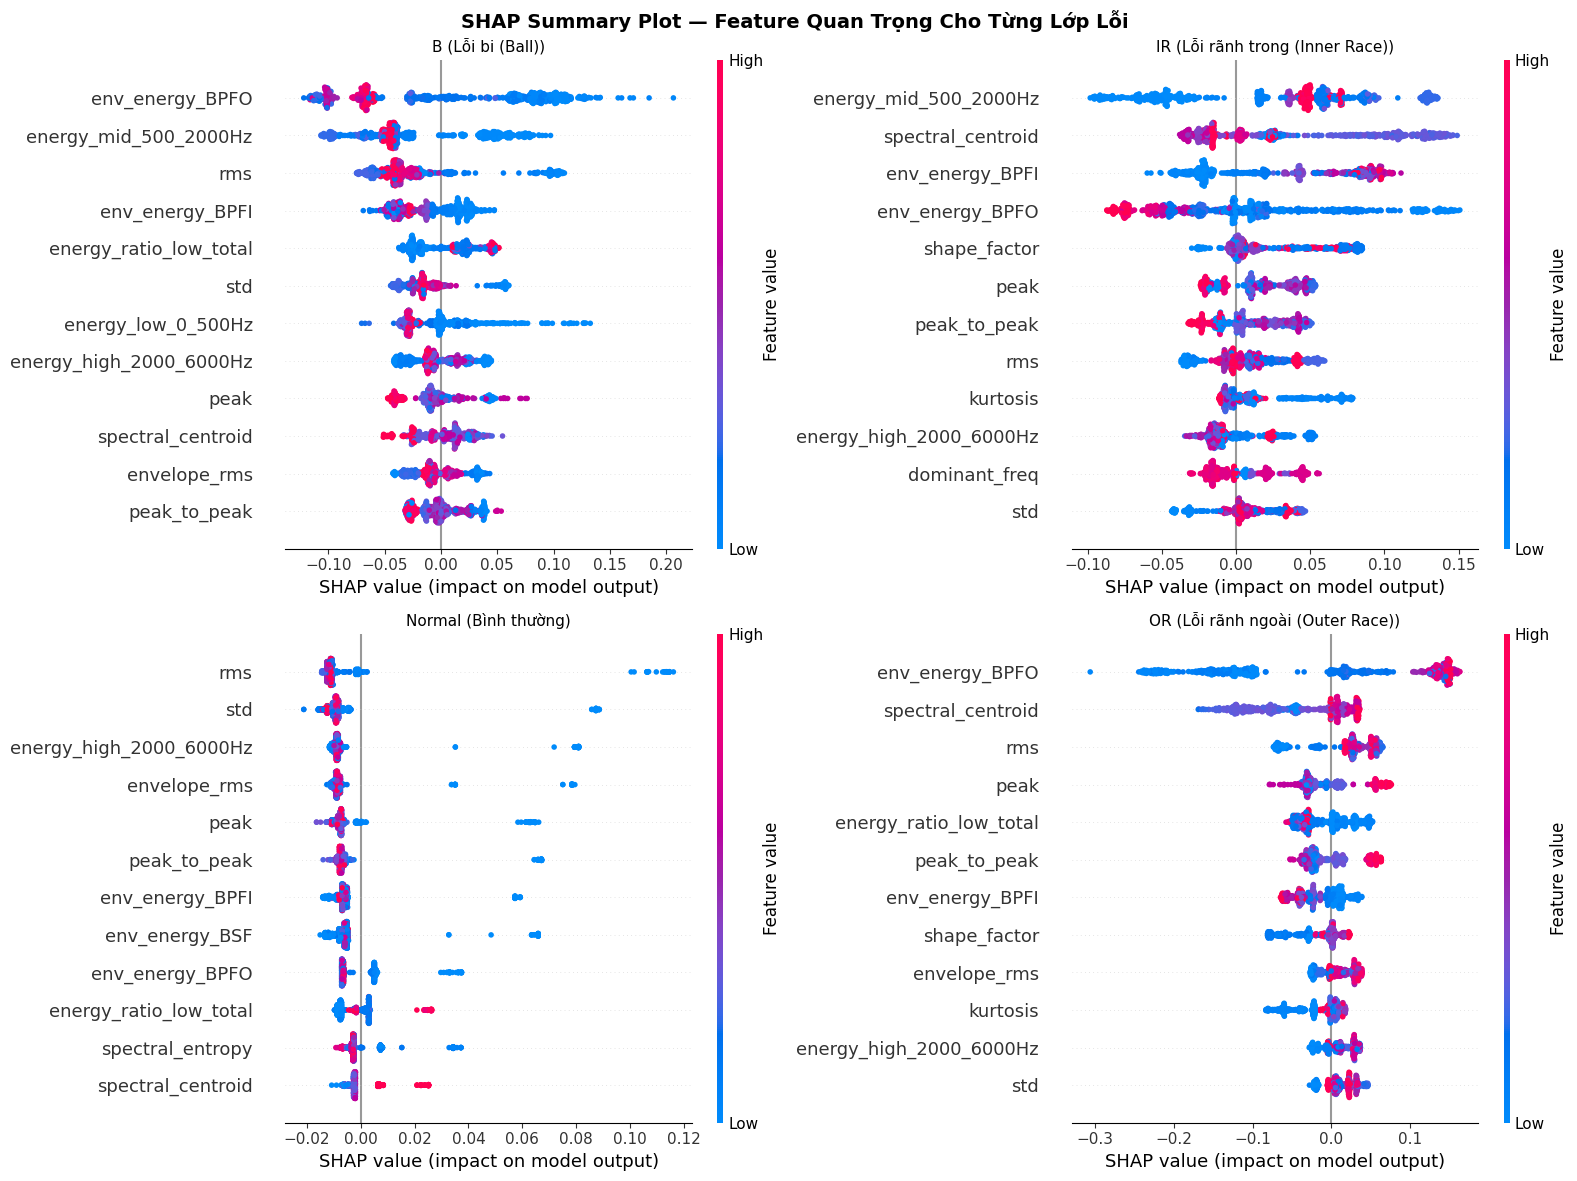

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('SHAP Summary Plot — Feature Quan Trọng Cho Từng Lớp Lỗi', fontsize=14, fontweight='bold')

for cls_idx, cls_name in enumerate(class_names):
    ax = axes[cls_idx // 2, cls_idx % 2]
    plt.sca(ax)
    # Fix: shap_values_rf[:, :, cls_idx] để lấy tất cả samples và features cho class cls_idx
    # (trước dùng shap_values_rf[cls_idx] sai vì nó lấy sample cls_idx, không phải class)
    shap.summary_plot(shap_values_rf[:, :, cls_idx], X_test_scaled,
                      feature_names=feature_names, max_display=12,
                      show=False, plot_size=None)
    ax.set_title(f'{cls_name} ({CLASS_DESC.get(cls_name, cls_name)})', fontsize=11)

plt.tight_layout()
plt.savefig('../figures/shap_summary_all_classes.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Waterfall Plot — Giải Thích Từng Mẫu Cụ Thể

### 🔍 Đọc Waterfall Plot Như Thế Nào?

- **Giá trị feature hiển thị:** Giá trị **VẬT LÝ THỰC** (ví dụ: kurtosis = 12.5) — KHÔNG phải z-score.
- **Thanh đỏ (→ phải):** Feature đẩy model về lớp này (bằng chứng ủng hộ).
- **Thanh xanh (← trái):** Feature kéo model ra xa lớp này (bằng chứng phản bác).
- **Base value:** Điểm xuất phát nếu không biết gì về mẫu.


WATERFALL — B (Lỗi bi (Ball))


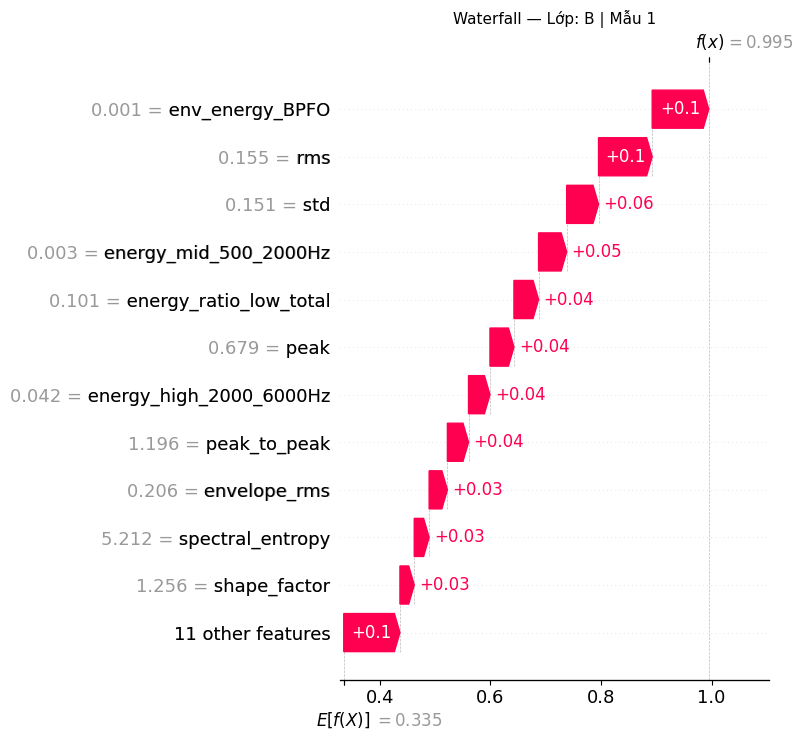


📋 Top 3 bằng chứng cho 'B' (Mẫu 1):
  1. env_energy_BPFO = 0.0010 → SHAP = +0.1023 (ủng hộ)
  2. rms = 0.1550 → SHAP = +0.0970 (ủng hộ)
  3. std = 0.1514 → SHAP = +0.0576 (ủng hộ)


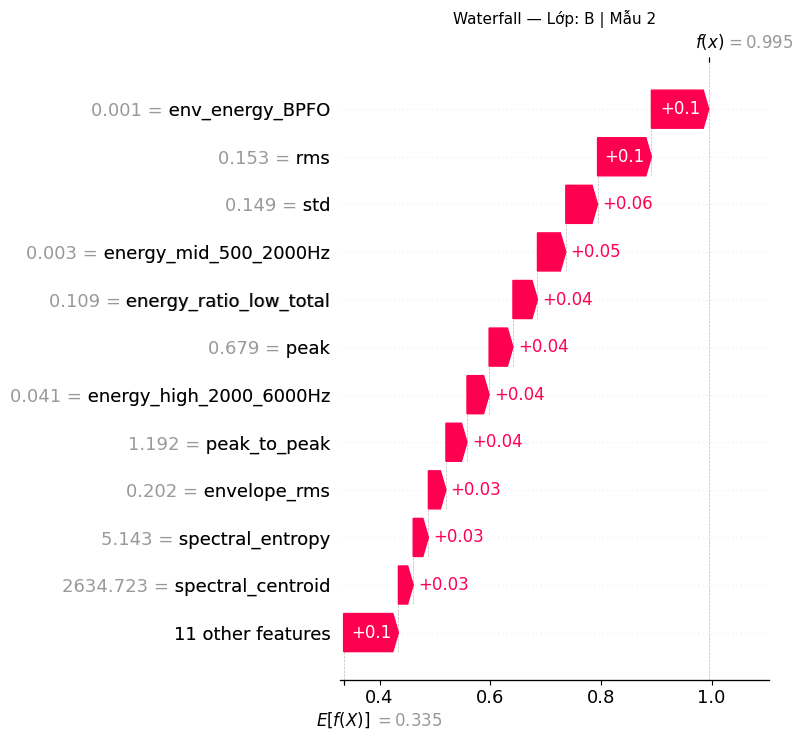


📋 Top 3 bằng chứng cho 'B' (Mẫu 2):
  1. env_energy_BPFO = 0.0009 → SHAP = +0.1037 (ủng hộ)
  2. rms = 0.1528 → SHAP = +0.0973 (ủng hộ)
  3. std = 0.1490 → SHAP = +0.0574 (ủng hộ)

WATERFALL — IR (Lỗi rãnh trong (Inner Race))


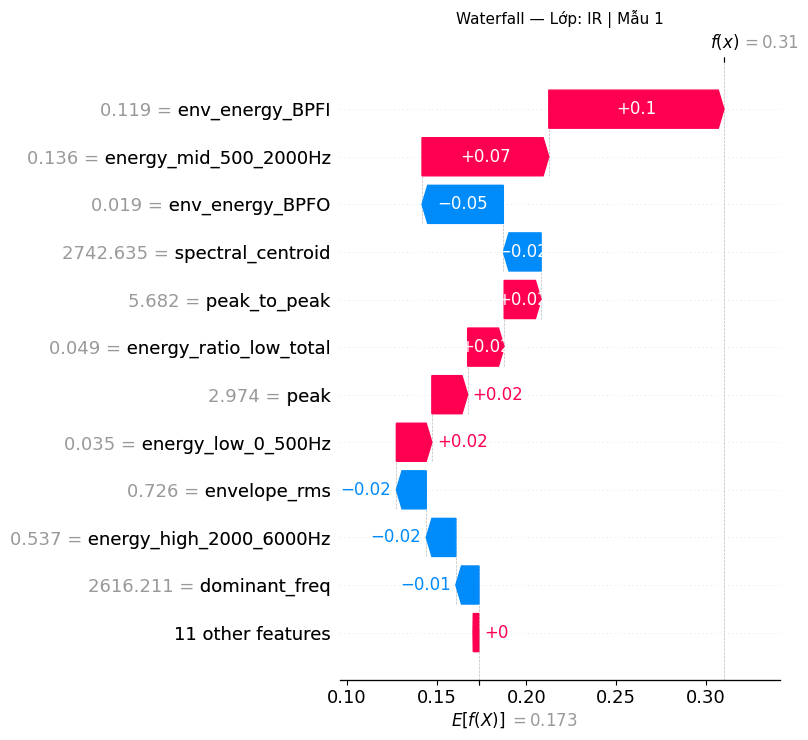


📋 Top 3 bằng chứng cho 'IR' (Mẫu 1):
  1. env_energy_BPFI = 0.1190 → SHAP = +0.0976 (ủng hộ)
  2. energy_mid_500_2000Hz = 0.1363 → SHAP = +0.0706 (ủng hộ)
  3. env_energy_BPFO = 0.0191 → SHAP = -0.0453 (phản bác)


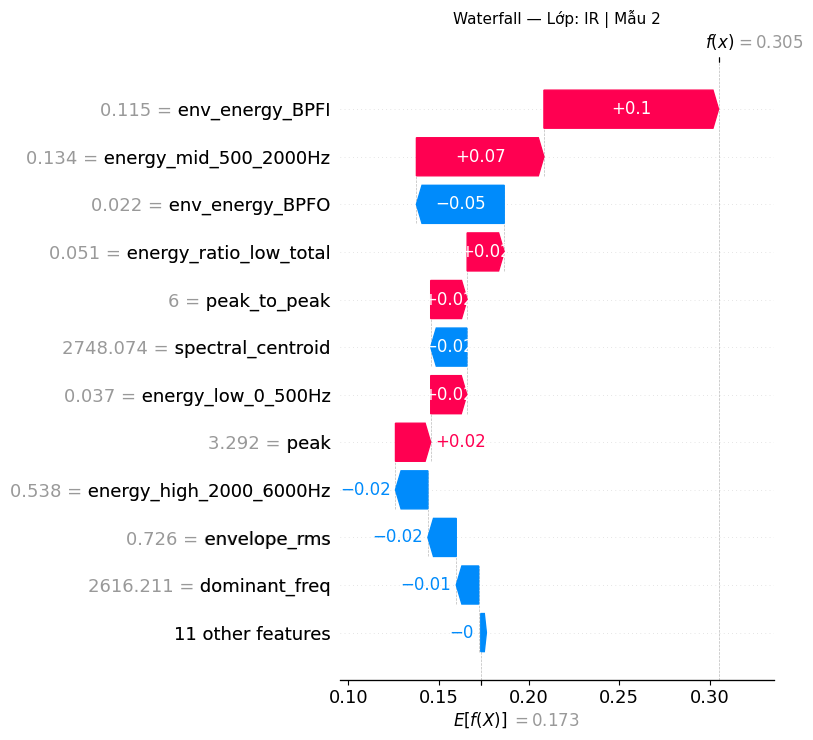


📋 Top 3 bằng chứng cho 'IR' (Mẫu 2):
  1. env_energy_BPFI = 0.1149 → SHAP = +0.0967 (ủng hộ)
  2. energy_mid_500_2000Hz = 0.1335 → SHAP = +0.0706 (ủng hộ)
  3. env_energy_BPFO = 0.0216 → SHAP = -0.0486 (phản bác)

WATERFALL — NORMAL (Bình thường)


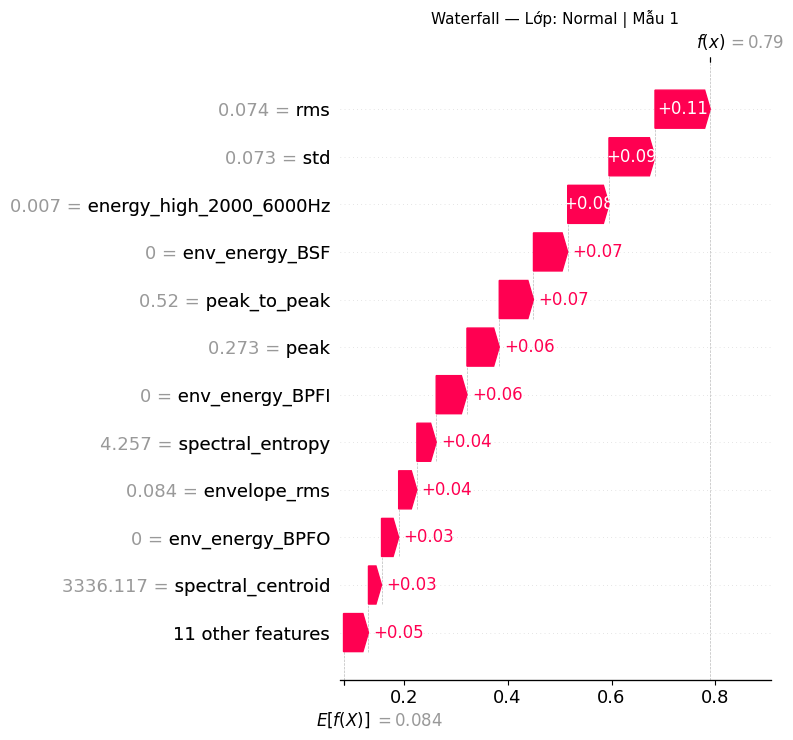


📋 Top 3 bằng chứng cho 'Normal' (Mẫu 1):
  1. rms = 0.0737 → SHAP = +0.1063 (ủng hộ)
  2. std = 0.0728 → SHAP = +0.0886 (ủng hộ)
  3. energy_high_2000_6000Hz = 0.0074 → SHAP = +0.0794 (ủng hộ)


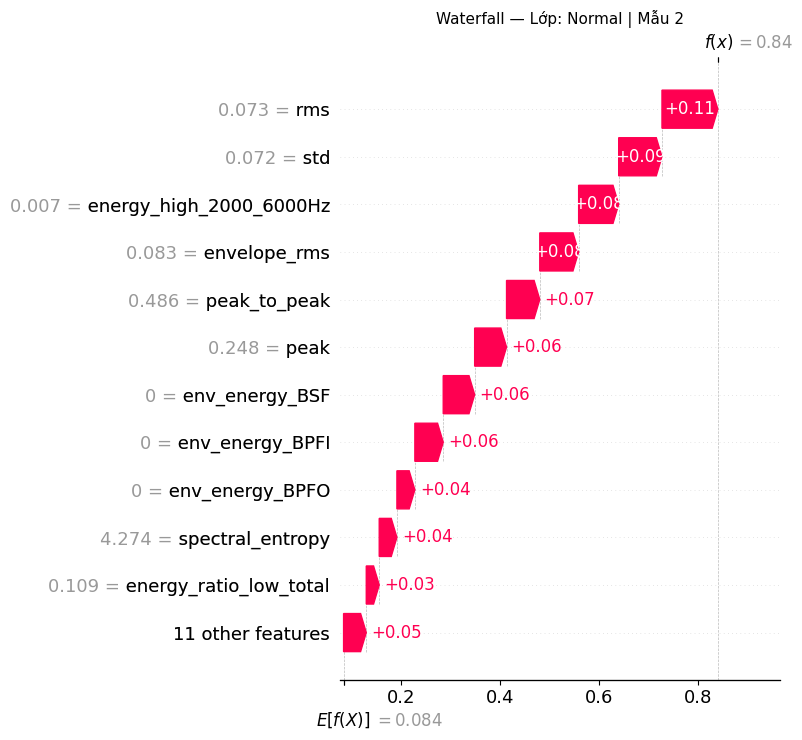


📋 Top 3 bằng chứng cho 'Normal' (Mẫu 2):
  1. rms = 0.0729 → SHAP = +0.1129 (ủng hộ)
  2. std = 0.0719 → SHAP = +0.0874 (ủng hộ)
  3. energy_high_2000_6000Hz = 0.0072 → SHAP = +0.0809 (ủng hộ)

WATERFALL — OR (Lỗi rãnh ngoài (Outer Race))


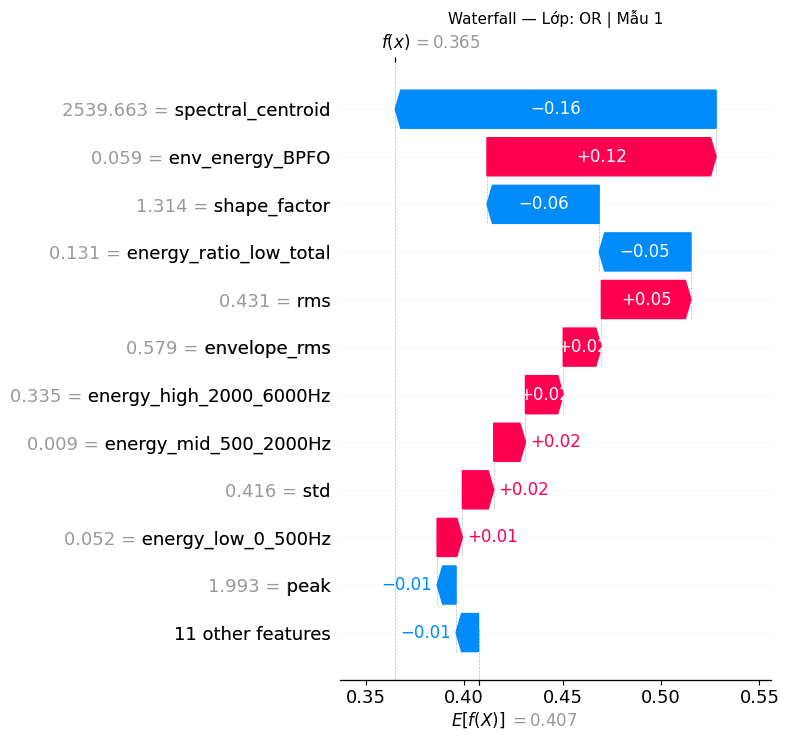


📋 Top 3 bằng chứng cho 'OR' (Mẫu 1):
  1. spectral_centroid = 2539.6633 → SHAP = -0.1630 (phản bác)
  2. env_energy_BPFO = 0.0586 → SHAP = +0.1164 (ủng hộ)
  3. shape_factor = 1.3143 → SHAP = -0.0570 (phản bác)


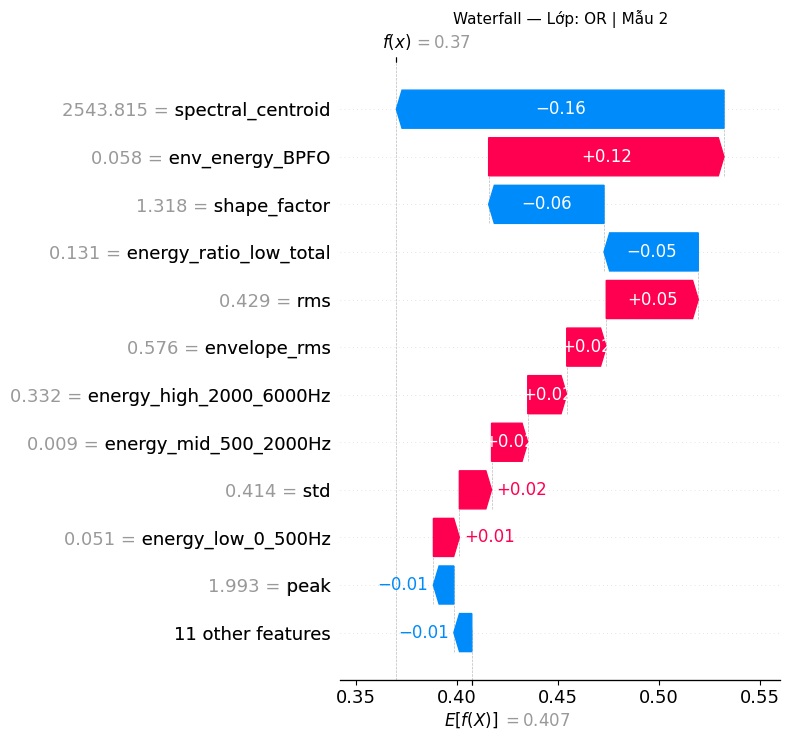


📋 Top 3 bằng chứng cho 'OR' (Mẫu 2):
  1. spectral_centroid = 2543.8154 → SHAP = -0.1621 (phản bác)
  2. env_energy_BPFO = 0.0575 → SHAP = +0.1165 (ủng hộ)
  3. shape_factor = 1.3181 → SHAP = -0.0571 (phản bác)


In [4]:
def plot_waterfall_for_class(cls_idx, cls_name, n_samples=2):
    cls_mask = (y_test_decoded == cls_name)
    cls_indices = np.where(cls_mask)[0]
    selected = cls_indices[:n_samples]

    for i, sample_idx in enumerate(selected):
        # SHAP trên scaled, nhưng HIỂN THỊ giá trị gốc (vật lý)
        # Fix: shap_values_rf[sample_idx, :, cls_idx] để lấy tất cả features cho sample_idx của class cls_idx
        explanation = shap.Explanation(
            values=shap_values_rf[sample_idx, :, cls_idx],  # shape (22,) - correct!
            base_values=explainer_rf.expected_value[cls_idx],
            data=X_test_df.iloc[sample_idx].values,  # ← Giá trị GỐC
            feature_names=feature_names
        )
        plt.figure(figsize=(10, 6))
        shap.plots.waterfall(explanation, max_display=12, show=False)
        plt.title(f'Waterfall — Lớp: {cls_name} | Mẫu {i+1}', fontsize=11)
        plt.tight_layout()
        plt.savefig(f'../figures/waterfall_{cls_name}_sample{i+1}.png', dpi=150, bbox_inches='tight')
        plt.show()

        # Top 3 bằng chứng
        # Fix: lấy giá trị tuyệt đối của shap_values_rf[sample_idx, :, cls_idx] cho class cls_idx
        top_idx = np.argsort(np.abs(shap_values_rf[sample_idx, :, cls_idx]))[-3:][::-1]
        print(f"\n📋 Top 3 bằng chứng cho '{cls_name}' (Mẫu {i+1}):")
        for rank, fi in enumerate(top_idx, 1):
            sv = shap_values_rf[sample_idx, fi, cls_idx]  # Fix: 3D indexing
            fv = X_test_df.iloc[sample_idx][feature_names[fi]]
            direction = "ủng hộ" if sv > 0 else "phản bác"
            print(f"  {rank}. {feature_names[fi]} = {fv:.4f} → SHAP = {sv:+.4f} ({direction})")

for cls_idx, cls_name in enumerate(class_names):
    print(f"\n{'='*60}")
    print(f"WATERFALL — {cls_name.upper()} ({CLASS_DESC.get(cls_name, '')})")
    plot_waterfall_for_class(cls_idx, cls_name, n_samples=2)

## 4. 🔧 Bảng SHAP → Cơ Chế Vật Lý → Hành Động Bảo Trì

| Feature SHAP dương cao | Cơ chế vật lý kỹ sư cần biết | Hành động khuyến nghị |
|---|---|---|
| **env_energy_BPFO** cao | Năng lượng envelope tại 107 Hz → bi qua vết lỗi rãnh NGOÀI cứ 9.3ms | ⚠️ Xác nhận OR. Chuẩn bị phụ tùng thay thế |
| **env_energy_BPFI** cao | Envelope tại 162 Hz + sidebands → lỗi rãnh TRONG, xung điều chế theo quay | 🔴 IR diễn biến nhanh hơn OR. Tăng giám sát, dừng máy sớm hơn |
| **env_energy_BSF** cao | Envelope tại 141 Hz → lỗi trên bề mặt bi | 🟡 Kiểm tra bôi trơn — lỗi bi thường do thiếu mỡ |
| **kurtosis** cao (>6) | Xung va chạm sắc nét, lặp có chu kỳ → điểm lỗi đã hình thành | ⚠️ Kurtosis >6: theo dõi; >10: hành động ngay |
| **envelope_kurtosis** cao | Xung trong đường bao rất sắc nét → va chạm rõ ở vùng cộng hưởng | Kết hợp env_energy để xác nhận loại lỗi |
| **crest_factor** cao (>8) | Peak/RMS lớn → xung đột biến mạnh so với nền rung | CF >6: theo dõi; >10: cần hành động. Theo ISO 10816 |
| **energy_low_0_500Hz** cao | Tăng năng lượng dải cơ bản — mất cân bằng (1X≈30Hz) HOẶC lỗi ổ lăn | Phân biệt: đỉnh rõ tại 30Hz = mất cân bằng; cần envelope để xác nhận |
| **rms** cao nhưng kurtosis thấp | Rung tổng thể tăng nhưng không có xung → looseness, misalignment | Không phải lỗi ổ lăn — kiểm tra bu-lông, alignment |

> ⚠️ **LƯU Ý:** Dải 500–2000 Hz là harmonics — KHÔNG phải nơi BPFO/BPFI/BSF cơ bản xuất hiện.
> BPFO=107Hz, BPFI=162Hz, BSF=141Hz đều ở dải **0–500 Hz**.

---
*Tutorial 05 hoàn tất. Tiếp theo: Tutorial 06 — Kết Luận & Khuyến Nghị.*